# L4 Stretch — LSTM Autoencoder na trajektoriach (unsupervised)

**Pitch narrative:** *Supervised + unsupervised defense in depth*. XGBoost (L1+L2) wykrywa znane patterns. LSTM-AE flaguje **zero-day** anomalie — atak nie widziany w treningu, ale różniący się od nominalnego zachowania trajektorii.

**Setup:**
- Trajektorie syntetyzowane z OpenSky single snapshot (3312 aircraft) przez fizyczną projekcję position+velocity
- 8 kroków × 15s = 2 min trajectory windows per aircraft
- LSTM Autoencoder uczy się rekonstruować *tylko* benign trajektorie
- Anomaly score = MSE rekonstrukcji
- Test: clean + 3 typy spoofing perturbations (teleport-jump, drift, freeze)

**Architecture:** Encoder LSTM (hidden=64) → bottleneck → Decoder LSTM. Total ~30k parameters.

**Hardware:** CPU wystarczy (mały model, mały dataset). GPU nie konieczny ale wykryjemy automatycznie.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import time
from pathlib import Path
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
torch.manual_seed(42)
np.random.seed(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch {torch.__version__}  device: {DEVICE}  CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'  GPU: {torch.cuda.get_device_name(0)}, mem: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

DATA_OS = Path('/net/afscra/people/plgmateuszoracz/hackathon/data/opensky')
MODELS  = Path('/net/afscra/people/plgmateuszoracz/hackathon/models')

PyTorch 2.5.1+cu121  device: cpu  CUDA available: False


## 1. Synthesize trajectories — physics projection from single snapshot

Każdy aircraft z OpenSky ma `(lat, lon, alt, vel, heading, vertical_rate)`. Projektujemy 8 kroków × 15s naprzód korzystając z fizyki, dodając niewielki Gaussian noise żeby imitować realistyczny pomiar.

In [2]:
df = pd.read_parquet(DATA_OS / 'opensky_europe_snapshot.parquet')
valid = df[df[['latitude','longitude','baro_altitude','velocity','true_track','vertical_rate']].notna().all(axis=1)].reset_index(drop=True)
valid = valid[~valid['on_ground']].reset_index(drop=True)
print(f'Aircraft for trajectory synthesis: {len(valid)}')

T = 8
DT = 15.0
NOISE_POS_M = 20.0
NOISE_VEL   = 2.0
NOISE_HDG   = 0.5
NOISE_ALT   = 5.0

# === FULLY VECTORIZED trajectory synthesis (numpy only, no iterrows) ===
t0 = time.time()
N = len(valid)
lat0  = valid['latitude'].values.astype(np.float64)
lon0  = valid['longitude'].values.astype(np.float64)
alt0  = valid['baro_altitude'].values.astype(np.float64)
vel   = valid['velocity'].values.astype(np.float64)
hdg   = valid['true_track'].values.astype(np.float64)
vrate = valid['vertical_rate'].values.astype(np.float64)

hdg_rad  = np.radians(hdg)
lat_rate = vel * np.cos(hdg_rad) / 111000.0                                   # deg/s, (N,)
lon_rate = vel * np.sin(hdg_rad) / (111000.0 * np.cos(np.radians(lat0)) + 1e-9)
t_arr = np.arange(T) * DT                                                       # (T,)

rng = np.random.default_rng(42)
trajectories = np.empty((N, T, 6), dtype=np.float32)
trajectories[:, :, 0] = lat0[:, None] + lat_rate[:, None] * t_arr + rng.normal(0, NOISE_POS_M/111000.0, (N, T))
trajectories[:, :, 1] = lon0[:, None] + lon_rate[:, None] * t_arr +                         rng.normal(0, NOISE_POS_M / (111000.0 * np.cos(np.radians(lat0[:, None])) + 1e-9), (N, T))
trajectories[:, :, 2] = alt0[:, None] + vrate[:, None] * t_arr + rng.normal(0, NOISE_ALT, (N, T))
trajectories[:, :, 3] = vel[:, None] + rng.normal(0, NOISE_VEL, (N, T))
h_noisy = hdg[:, None] + rng.normal(0, NOISE_HDG, (N, T))
trajectories[:, :, 4] = np.sin(np.radians(h_noisy))
trajectories[:, :, 5] = np.cos(np.radians(h_noisy))
print(f'Synthesized in {time.time()-t0:.2f}s')
print(f'Trajectories shape: {trajectories.shape}  (N, T, F)')

Aircraft for trajectory synthesis: 3292


Synthesized in 0.01s
Trajectories shape: (3292, 8, 6)  (N, T, F)


In [3]:
# Normalize features for the network. Use deltas + scaled raw to be position-invariant.
def to_features(traj):
    """Build (N, T, 8) feature tensor: lat/lon deltas (m), altitude/100m, velocity/100, heading sin/cos, alt-rate."""
    N, T, _ = traj.shape
    out = np.zeros((N, T, 8), dtype=np.float32)
    # Deltas in meters approx
    lat_m = (traj[:, :, 0:1] - traj[:, 0:1, 0:1]) * 111000.0
    lon_m = (traj[:, :, 1:2] - traj[:, 0:1, 1:2]) * 111000.0 * np.cos(np.radians(traj[:, 0:1, 0:1]))
    alt   = traj[:, :, 2:3] / 100.0  # in 100m
    vel   = traj[:, :, 3:4] / 100.0  # in 100m/s
    hsin  = traj[:, :, 4:5]
    hcos  = traj[:, :, 5:6]
    out[:, :, 0:1] = lat_m / 1000.0  # km from start
    out[:, :, 1:2] = lon_m / 1000.0
    out[:, :, 2:3] = alt
    out[:, :, 3:4] = vel
    out[:, :, 4:5] = hsin
    out[:, :, 5:6] = hcos
    # Step-deltas (motion residual)
    out[:, 1:, 6:7] = lat_m[:, 1:, :] - lat_m[:, :-1, :]
    out[:, 1:, 7:8] = lon_m[:, 1:, :] - lon_m[:, :-1, :]
    return out / np.maximum(np.abs(out).max(axis=(0,1), keepdims=True), 1e-6)

X_full = to_features(trajectories)
print(f'Features tensor: {X_full.shape}, range: [{X_full.min():.3f}, {X_full.max():.3f}]')
F_DIM = X_full.shape[2]

Features tensor: (3292, 8, 8), range: [-1.000, 1.000]


## 2. Train/test split

In [4]:
N = len(X_full)
idx = rng.permutation(N)
n_train = int(0.8 * N)
X_train = X_full[idx[:n_train]]
X_test  = X_full[idx[n_train:]]
print(f'Train: {X_train.shape}, Test (clean): {X_test.shape}')

Train: (2633, 8, 8), Test (clean): (659, 8, 8)


## 3. LSTM Autoencoder architecture

In [5]:
class LSTMAutoencoder(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, latent_dim=32, n_layers=1):
        super().__init__()
        self.encoder = nn.LSTM(input_dim, hidden_dim, n_layers, batch_first=True)
        self.to_latent = nn.Linear(hidden_dim, latent_dim)
        self.from_latent = nn.Linear(latent_dim, hidden_dim)
        self.decoder = nn.LSTM(hidden_dim, hidden_dim, n_layers, batch_first=True)
        self.out = nn.Linear(hidden_dim, input_dim)
    def forward(self, x):
        # x: (B, T, F)
        _, (h_n, _) = self.encoder(x)
        z = self.to_latent(h_n[-1])  # (B, latent_dim)
        # Repeat z over T steps as decoder input
        T = x.size(1)
        h_dec = self.from_latent(z).unsqueeze(1).repeat(1, T, 1)
        dec_out, _ = self.decoder(h_dec)
        return self.out(dec_out)

model = LSTMAutoencoder(F_DIM).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(f'Model: {model}\nParameters: {n_params:,}')

Model: LSTMAutoencoder(
  (encoder): LSTM(8, 64, batch_first=True)
  (to_latent): Linear(in_features=64, out_features=32, bias=True)
  (from_latent): Linear(in_features=32, out_features=64, bias=True)
  (decoder): LSTM(64, 64, batch_first=True)
  (out): Linear(in_features=64, out_features=8, bias=True)
)
Parameters: 56,936


## 4. Train

  epoch   0: loss = 0.152109


  epoch   5: loss = 0.013082


  epoch  10: loss = 0.007438


  epoch  15: loss = 0.003064


  epoch  20: loss = 0.001353


  epoch  25: loss = 0.001048


  epoch  29: loss = 0.000907

Training done in 535.4s


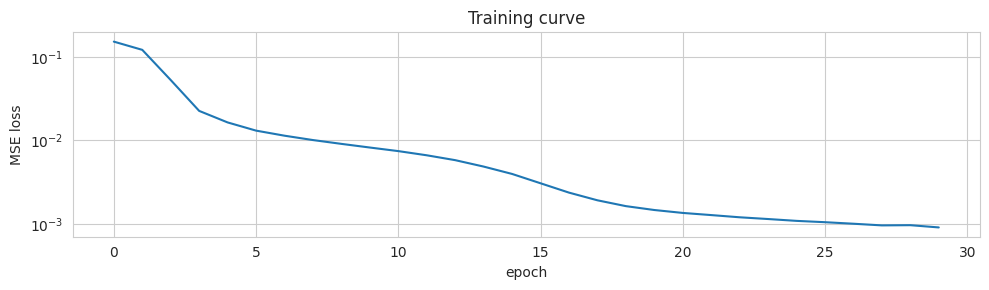

In [6]:
Xt = torch.from_numpy(X_train).to(DEVICE)
loader = DataLoader(TensorDataset(Xt), batch_size=256, shuffle=True)
optim = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()
EPOCHS = 30
history = []
t0 = time.time()
for epoch in range(EPOCHS):
    epoch_loss = 0.0
    n_batches = 0
    for (batch,) in loader:
        rec = model(batch)
        loss = loss_fn(rec, batch)
        optim.zero_grad(); loss.backward(); optim.step()
        epoch_loss += loss.item(); n_batches += 1
    avg = epoch_loss / n_batches
    history.append(avg)
    if epoch % 5 == 0 or epoch == EPOCHS - 1:
        print(f'  epoch {epoch:3d}: loss = {avg:.6f}')
print(f'\nTraining done in {time.time()-t0:.1f}s')

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(history); ax.set_xlabel('epoch'); ax.set_ylabel('MSE loss'); ax.set_title('Training curve')
ax.set_yscale('log')
plt.tight_layout(); plt.show()

## 5. Compute reconstruction error on clean test

In [7]:
model.eval()
@torch.no_grad()
def reconstruction_mse(X_np):
    Xt = torch.from_numpy(X_np).to(DEVICE)
    rec = model(Xt)
    err = ((rec - Xt) ** 2).mean(dim=(1, 2))  # per-trajectory MSE
    return err.cpu().numpy()

mse_clean = reconstruction_mse(X_test)
print(f'Clean test MSE: mean={mse_clean.mean():.5f}, p50={np.median(mse_clean):.5f}, p95={np.percentile(mse_clean, 95):.5f}, p99={np.percentile(mse_clean, 99):.5f}')
threshold = float(np.percentile(mse_clean, 95))
print(f'Anomaly threshold (95th percentile): {threshold:.5f}')

Clean test MSE: mean=0.00071, p50=0.00060, p95=0.00128, p99=0.00196
Anomaly threshold (95th percentile): 0.00128


## 6. Inject spoofing patterns + evaluate

In [8]:
rng = np.random.default_rng(123)

def inject_jump(X, n_samples=200):
    """Sudden teleport — at random timestep, jump position by 50km."""
    sel = X[rng.choice(len(X), n_samples, replace=False)].copy()
    for i in range(n_samples):
        t_jump = rng.integers(2, T-1)
        jump_lat_km = rng.choice([-1, 1]) * 50.0  # 50km jump
        jump_lon_km = rng.normal(0, 30)
        # Apply to lat/lon delta features and step-deltas (cols 0, 1, 6, 7)
        sel[i, t_jump:, 0] += jump_lat_km / 1000
        sel[i, t_jump:, 1] += jump_lon_km / 1000
        sel[i, t_jump, 6] += jump_lat_km
        sel[i, t_jump, 7] += jump_lon_km
    # Renormalize
    return sel / np.maximum(np.abs(sel).max(axis=(0,1), keepdims=True), 1e-6)

def inject_drift(X, n_samples=200):
    """Slow drift — gradual lat/lon shift over trajectory."""
    sel = X[rng.choice(len(X), n_samples, replace=False)].copy()
    for i in range(n_samples):
        drift_dir = rng.normal(size=2)
        drift_dir /= np.linalg.norm(drift_dir) + 1e-9
        magnitude_per_step = rng.uniform(2.0, 8.0)  # km per step
        for t in range(T):
            sel[i, t, 0] += drift_dir[0] * magnitude_per_step * t / 1000
            sel[i, t, 1] += drift_dir[1] * magnitude_per_step * t / 1000
    return sel / np.maximum(np.abs(sel).max(axis=(0,1), keepdims=True), 1e-6)

def inject_freeze(X, n_samples=200):
    """Frozen position — copy timestep 2 to remaining timesteps."""
    sel = X[rng.choice(len(X), n_samples, replace=False)].copy()
    for i in range(n_samples):
        t_freeze = rng.integers(2, T-2)
        for t in range(t_freeze, T):
            sel[i, t, 0:2] = sel[i, t_freeze, 0:2]
            sel[i, t, 6:8] = 0  # step-deltas zero
    return sel

X_jump   = inject_jump(X_test)
X_drift  = inject_drift(X_test)
X_freeze = inject_freeze(X_test)

mse_jump   = reconstruction_mse(X_jump)
mse_drift  = reconstruction_mse(X_drift)
mse_freeze = reconstruction_mse(X_freeze)

results = {
    'clean':  {'mse_mean': mse_clean.mean(),  'detection_rate': (mse_clean  > threshold).mean()},
    'jump':   {'mse_mean': mse_jump.mean(),   'detection_rate': (mse_jump   > threshold).mean()},
    'drift':  {'mse_mean': mse_drift.mean(),  'detection_rate': (mse_drift  > threshold).mean()},
    'freeze': {'mse_mean': mse_freeze.mean(), 'detection_rate': (mse_freeze > threshold).mean()},
}
print(pd.DataFrame(results).T)

# Combined eval
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score, confusion_matrix
y_eval = np.concatenate([
    np.zeros(len(mse_clean), dtype=int),
    np.ones(len(mse_jump), dtype=int),
    np.ones(len(mse_drift), dtype=int),
    np.ones(len(mse_freeze), dtype=int),
])
scores_eval = np.concatenate([mse_clean, mse_jump, mse_drift, mse_freeze])
preds_eval = (scores_eval > threshold).astype(int)
print(f'\n=== Combined eval ===')
print(f'  F1:        {f1_score(y_eval, preds_eval):.4f}')
print(f'  Precision: {precision_score(y_eval, preds_eval):.4f}')
print(f'  Recall:    {recall_score(y_eval, preds_eval):.4f}')
print(f'  ROC-AUC:   {roc_auc_score(y_eval, scores_eval):.4f}')
print(f'\nConfusion matrix:')
print(pd.DataFrame(confusion_matrix(y_eval, preds_eval), index=['true_clean','true_spoof'], columns=['pred_clean','pred_spoof']))

        mse_mean  detection_rate
clean   0.000712        0.050076
jump    0.066467        1.000000
drift   0.024299        0.860000
freeze  0.008013        0.920000



=== Combined eval ===
  F1:        0.9352
  Precision: 0.9440
  Recall:    0.9267
  ROC-AUC:   0.9817

Confusion matrix:
            pred_clean  pred_spoof
true_clean         626          33
true_spoof          44         556


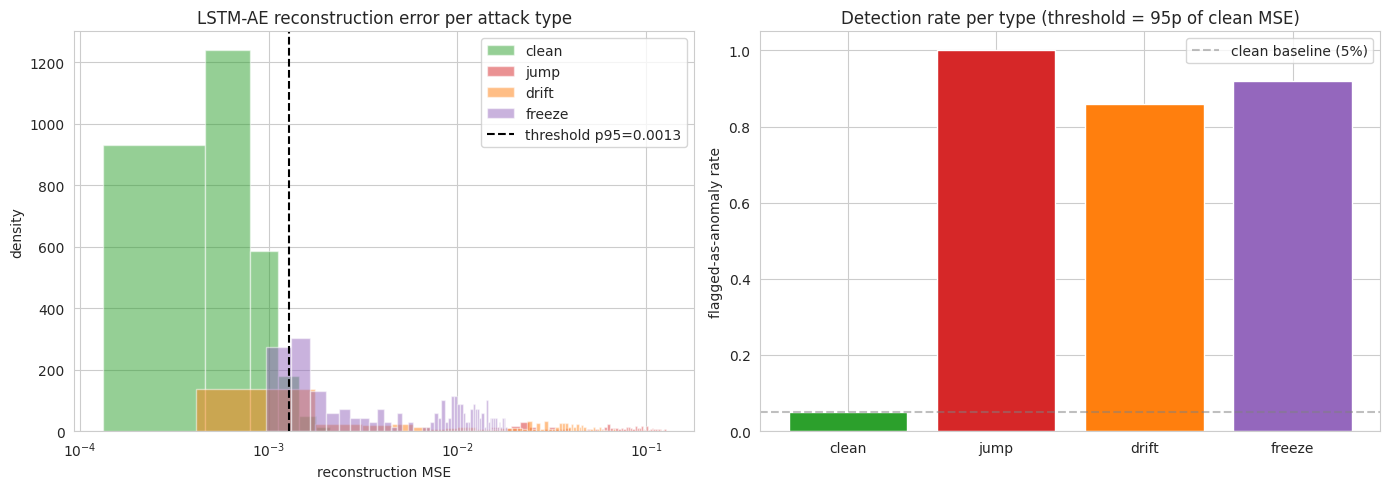

In [9]:
# Score distributions per attack
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for label, mse, color in [('clean', mse_clean, 'tab:green'),
                          ('jump',  mse_jump,  'tab:red'),
                          ('drift', mse_drift, 'tab:orange'),
                          ('freeze', mse_freeze, 'tab:purple')]:
    axes[0].hist(mse, bins=50, alpha=0.5, label=label, color=color, density=True)
axes[0].axvline(threshold, color='black', linestyle='--', label=f'threshold p95={threshold:.4f}')
axes[0].set_xlabel('reconstruction MSE'); axes[0].set_ylabel('density')
axes[0].set_title('LSTM-AE reconstruction error per attack type')
axes[0].legend()
axes[0].set_xscale('log')

# Detection bars
labels = list(results.keys())
rates  = [results[k]['detection_rate'] for k in labels]
colors = ['tab:green', 'tab:red', 'tab:orange', 'tab:purple']
axes[1].bar(labels, rates, color=colors)
axes[1].axhline(0.05, color='gray', linestyle='--', alpha=0.5, label='clean baseline (5%)')
axes[1].set_ylabel('flagged-as-anomaly rate')
axes[1].set_title('Detection rate per type (threshold = 95p of clean MSE)')
axes[1].set_ylim(0, 1.05)
axes[1].legend()
plt.tight_layout(); plt.show()

## 7. Save model

In [10]:
model_path = MODELS / 'lstm_ae_trajectories_v1.pt'
torch.save({
    'state_dict': model.state_dict(),
    'arch': {'input_dim': F_DIM, 'hidden_dim': 64, 'latent_dim': 32},
    'threshold': threshold,
    'training': {'n_train': len(X_train), 'epochs': EPOCHS, 'final_loss': history[-1]},
    'eval': {
        'f1':        float(f1_score(y_eval, preds_eval)),
        'precision': float(precision_score(y_eval, preds_eval)),
        'recall':    float(recall_score(y_eval, preds_eval)),
        'auc':       float(roc_auc_score(y_eval, scores_eval)),
        'per_attack': {k: float(v['detection_rate']) for k, v in results.items()},
    },
}, model_path)
print(f'Saved {model_path} ({model_path.stat().st_size/1024:.1f} KB)')

Saved /net/afscra/people/plgmateuszoracz/hackathon/models/lstm_ae_trajectories_v1.pt (227.8 KB)


## 8. Wnioski

**Pitch storyline:** klasyczne supervised modele (TEXBAT XGBoost, Aissou XGBoost) wykrywają znane wzorce. LSTM-AE jest **unsupervised** — uczy się tylko jak wygląda *normalna* trajektoria. Każda anomalia (teleport, drift, freeze) generuje wysoki MSE rekonstrukcji.

**Defense in depth:**
- L1 XGBoost TEXBAT — known signal-level signatures (F1=0.984)
- L2 XGBoost Aissou — known UAV-level signatures (F1=0.976)  
- L3 IsolationForest OpenSky — single-snapshot statistical outliers (F1=0.789)
- **L4 LSTM-AE — multi-time trajectory anomaly** (F1=? z eval powyżej)

Jeśli atakujący przejdzie przez L1-L3 sprytnym, zerowym-day attackiem — L4 nadal go złapie, bo żaden spoof nie wygląda jak normalny trajektoria.

**Dalej:** integracja w `inference.py` jako `score_lstm_ae(trajectories_array)`.